<a href="https://colab.research.google.com/github/Sajina-S/fraud-detection-bank-payments/blob/main/fraud_detection_bank_payments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context
Banks are often exposed to fraud transactions and constantly improve systems to track them.
# Content
Bank dataset that contains 20k+ transactions with 112 features

#1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#2. Load Dataset & Exploring Data

In [ ]:
df = pd.read_csv("/content/fraud_detection_bank_dataset.csv")
df.head()

,Unnamed: 0,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,...,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111,targets
0,0,9,1354,0,18,0,1,7,9,0,...,0,0,0,1,1,0,0,0,49,1
1,1,0,239,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,55,1
2,2,0,260,0,4,0,3,6,0,0,...,0,0,0,1,1,0,0,0,56,1
3,3,17,682,0,1,0,0,8,17,0,...,0,1,0,1,1,0,0,0,65,1
4,4,1,540,0,2,0,1,7,1,0,...,0,0,0,1,1,0,0,0,175,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20468 entries, 0 to 20467
Columns: 114 entries, Unnamed: 0 to targets
dtypes: float64(1), int64(113)
memory usage: 17.8 MB


In [ ]:
df.describe()

,Unnamed: 0,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,...,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111,targets
count,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.0,...,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000,20468.000000
mean,10233.500000,3.226256,294.793043,0.420021,2.329343,0.083594,0.939857,2.386066,3.226256,0.0,...,0.004935,0.358120,0.002443,0.308384,0.190737,0.000049,0.049345,0.024282,43.486125,0.265683
std,5908.746991,20.564308,717.541984,7.367275,10.068512,0.840537,4.222896,3.018140,20.564308,0.0,...,0.073478,0.479459,0.049366,0.461837,0.392892,0.006990,0.216593,0.305079,59.217560,0.441707
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5116.750000,0.000000,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
50%,10233.500000,0.000000,97.000000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000
75%,15350.250000,2.000000,283.000000,0.000000,2.000000,0.000000,1.000000,6.000000,2.000000,0.0,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,61.250000,1.000000
max,20467.000000,2301.000000,37808.000000,904.000000,772.000000,54.000000,230.000000,11.000000,2301.000000,0.0,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,17.000000,747.000000,1.000000


In [ ]:
df.isnull().sum()

Unnamed: 0    0
col_0         0
col_1         0
col_2         0
col_3         0
             ..
col_108       0
col_109       0
col_110       0
col_111       0
targets       0
Length: 114, dtype: int64

In [ ]:
df.columns

Index(['Unnamed: 0', 'col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5',
       'col_6', 'col_7', 'col_8',
       ...
       'col_103', 'col_104', 'col_105', 'col_106', 'col_107', 'col_108',
       'col_109', 'col_110', 'col_111', 'targets'],
      dtype='object', length=114)

In [ ]:
df.shape

(20468, 114)

In [ ]:
df.dtypes

Unnamed: 0    int64
col_0         int64
col_1         int64
col_2         int64
col_3         int64
              ...  
col_108       int64
col_109       int64
col_110       int64
col_111       int64
targets       int64
Length: 114, dtype: object

In [ ]:
df.nunique()

Unnamed: 0    20468
col_0           142
col_1          1920
col_2            53
col_3           115
              ...  
col_108           2
col_109           2
col_110          13
col_111         381
targets           2
Length: 114, dtype: int64

,Unnamed: 0,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,...,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111,targets
Unnamed: 0,1.000000,0.029158,0.078520,0.022861,0.062289,-0.016648,-0.043268,0.011731,0.029158,NaN,...,0.027124,-0.209677,-0.026020,0.199142,0.138814,-0.004183,-0.131745,-0.063778,-0.210310,-0.765040
col_0,0.029158,1.000000,0.551274,0.005679,0.077408,-0.002019,0.037343,0.011153,1.000000,NaN,...,0.009964,-0.009675,0.003354,0.075413,0.078262,0.000603,0.011074,0.015806,0.052114,-0.041022
col_1,0.078520,0.551274,1.000000,0.301637,0.280233,0.102733,0.246112,0.008418,0.551274,NaN,...,0.077884,0.021930,0.031179,0.232897,0.290501,-0.001469,0.088685,0.111713,0.206308,-0.109658
col_2,0.022861,0.005679,0.301637,1.000000,0.018034,0.068560,-0.009578,0.001042,0.005679,NaN,...,0.024692,0.001027,0.009001,0.041971,0.054846,0.005294,0.029326,0.009831,0.033094,-0.026381
col_3,0.062289,0.077408,0.280233,0.018034,1.000000,-0.012554,-0.015184,-0.044345,0.077408,NaN,...,0.091980,-0.038370,0.046253,0.148617,0.199203,-0.001617,0.070381,0.049871,0.127431,-0.095612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
col_108,-0.004183,0.000603,-0.001469,0.005294,-0.001617,-0.000695,-0.001556,-0.000894,0.000603,NaN,...,-0.000469,-0.005221,-0.000346,0.010468,0.014398,1.000000,0.030680,-0.000556,0.013871,-0.004204
col_109,-0.131745,0.011074,0.088685,0.029326,0.070381,0.051145,0.124398,-0.003134,0.011074,NaN,...,0.082940,0.107412,0.061839,0.057408,0.114461,0.030680,1.000000,0.139361,0.369065,0.166826
col_110,-0.063778,0.015806,0.111713,0.009831,0.049871,0.006374,0.116577,-0.008749,0.015806,NaN,...,0.040426,0.003011,0.200445,0.061286,0.150089,-0.000556,0.139361,1.000000,0.334947,0.071049
col_111,-0.210310,0.052114,0.206308,0.033094,0.127431,0.056226,0.223831,0.021537,0.052114,NaN,...,0.136194,0.402607,0.124260,0.221531,0.329699,0.013871,0.369065,0.334947,1.000000,0.262442


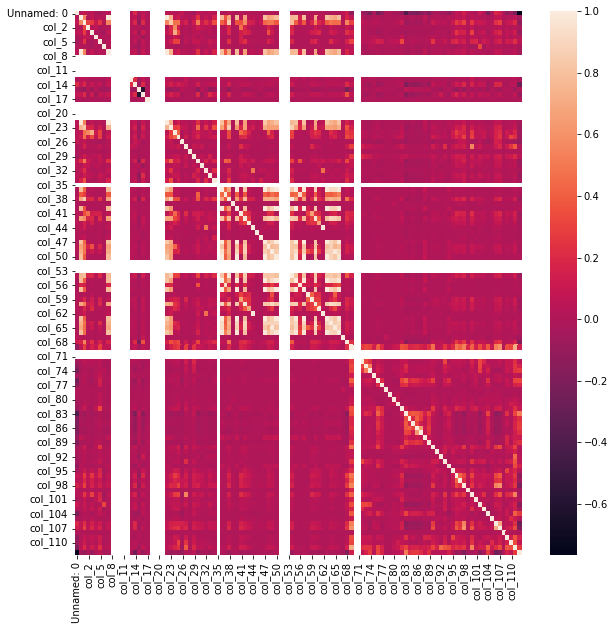

In [ ]:
from seaborn import heatmap
fig, ax = plt.subplots(figsize=(10,10))
heatmap(data=df.corr())
df.corr()

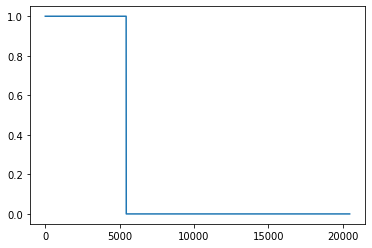

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df['targets'])

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


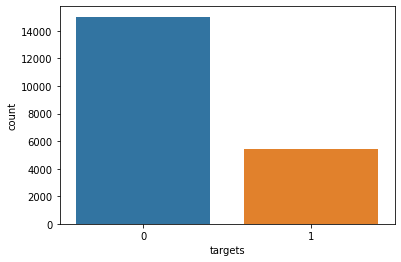

Ratio Target Class


0    15030
1     5438
Name: targets, dtype: int64

In [ ]:
#A count plot can be thought of as a histogram across a categorical, instead of quantitative, variable.Show the counts of observations in each categorical bin using bars.
sns.countplot(df['targets'])
plt.show()

print('Ratio Target Class')
df['targets'].value_counts()


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f83f6b94950>,
      dtype=object)

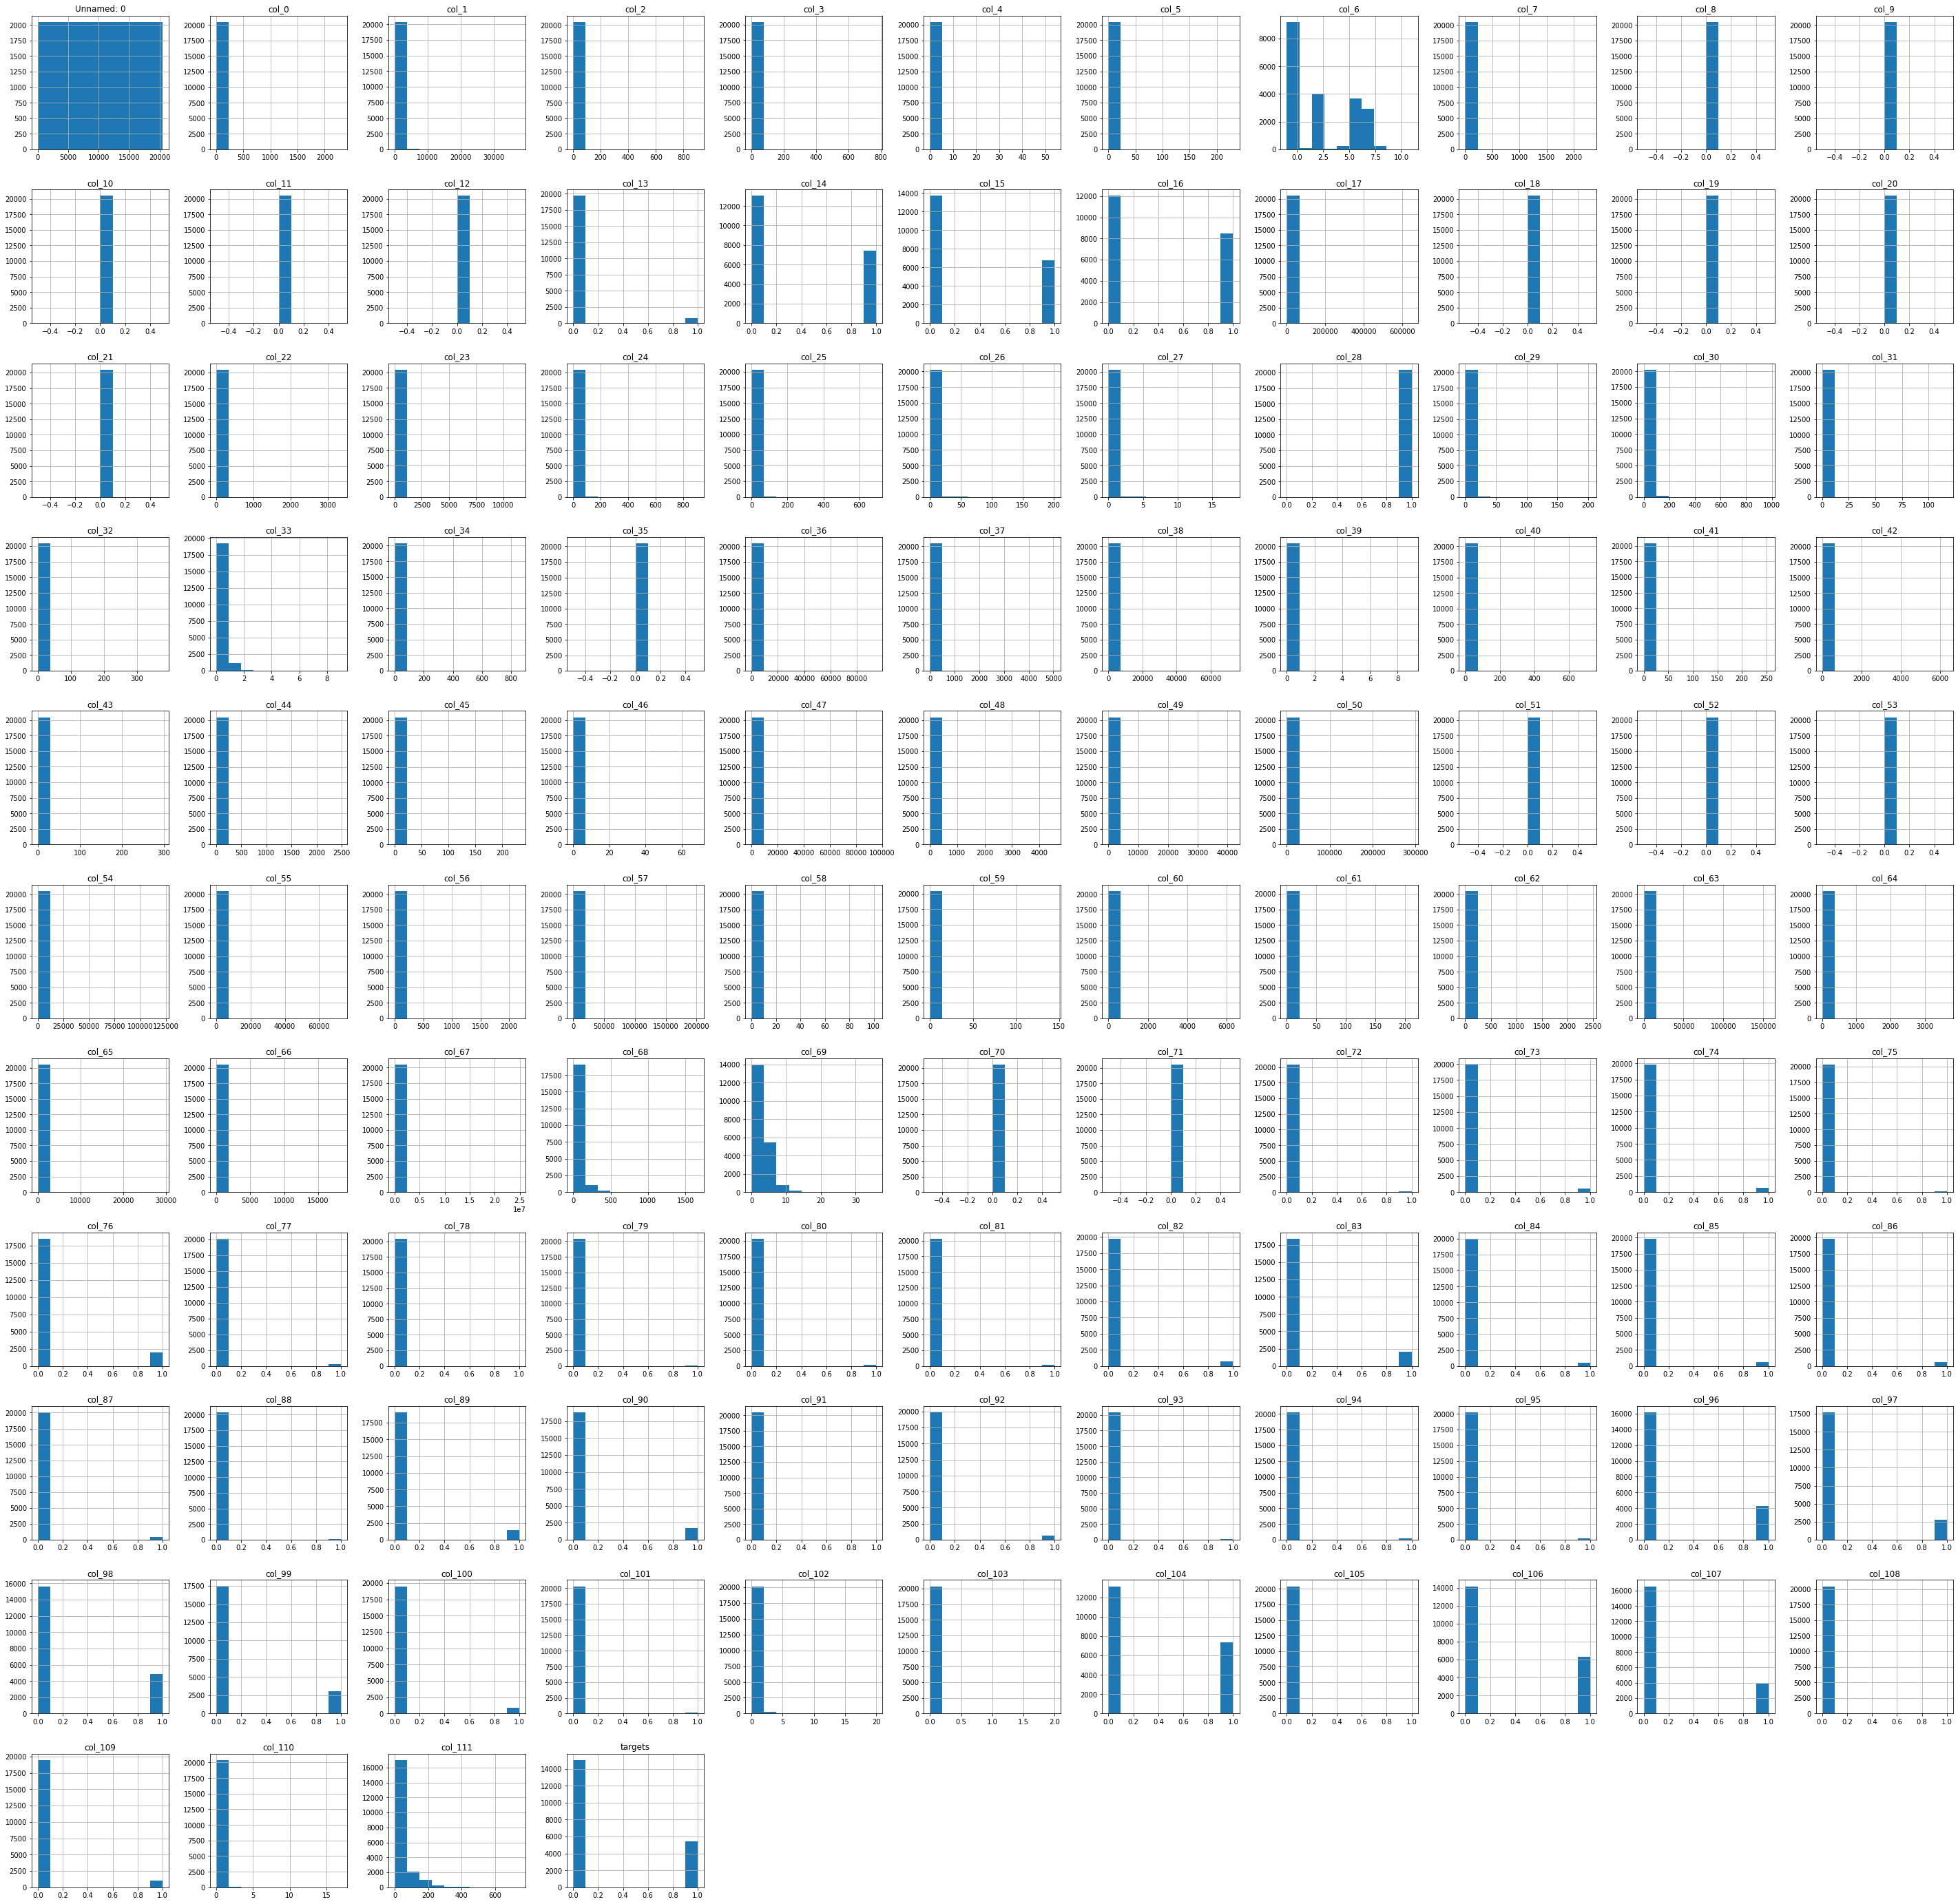

In [ ]:
df.hist(figsize=(50,50))

Text(0.5, 1.0, 'Box plot of targets column ')

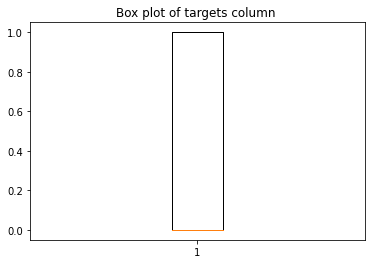

In [ ]:
plt.boxplot(df['targets'])                             #outlier detection using boxplot
plt.title('Box plot of targets column ')

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:316: UserWarning: Dataset has 0 variance; skipping density e

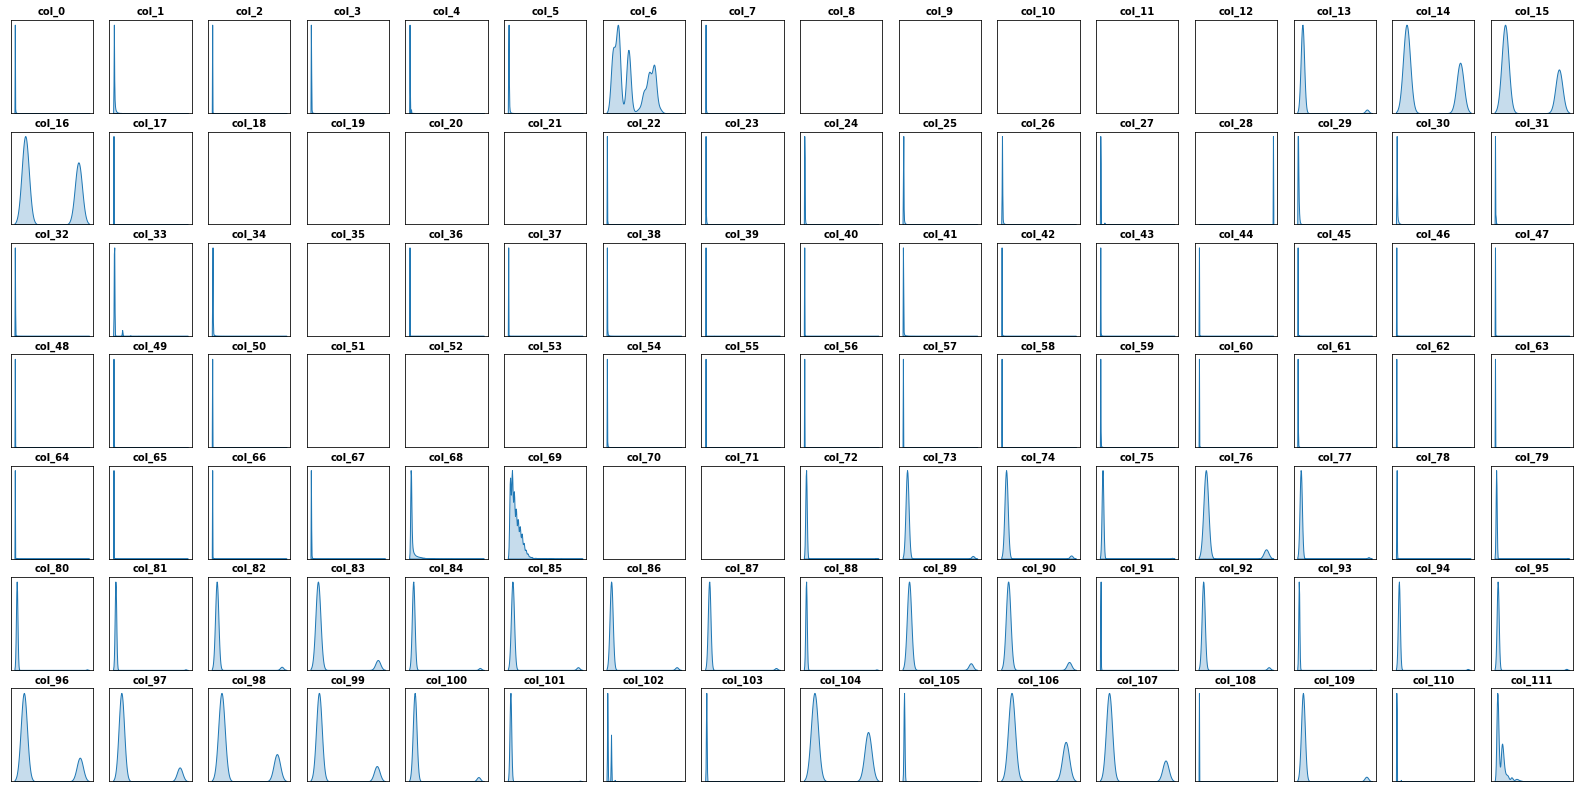

In [ ]:
fig, axes = plt.subplots(7,16,figsize=(28,14))
axes = axes.flatten()

for col, ax in enumerate(axes):
    sns.kdeplot(data=df, x=f'col_{col}',
                fill=True,
                ax=ax)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'col_{col}', loc='center', weight='bold', fontsize=10)

plt.show()

# 3. Data preprocesing

In [ ]:
# first columns is redundant
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
missing_count = df.isnull().any().sum()
print(f'Count of features with missing values: {missing_count}')

Count of features with missing values: 0


In [ ]:
df['targets'].value_counts()

0    15030
1     5438
Name: targets, dtype: int64

Our datasets is Imbalanced so it may increase error so make it balanced

In [ ]:
df_0 = df[df['targets']==0][:5438]
df_0['targets'].value_counts()

0    5438
Name: targets, dtype: int64

In [ ]:
df_1 = df[df['targets'] == 1]
df_1.shape

(5438, 113)

concat df_0 and df_1

In [ ]:
df = pd.concat([df_0, df_1], axis=0)
df.shape

(10876, 113)

#4. Standardize Data and Feature Extraction with PCA
I will standardize the data and do PCA to extract the features into 17 components so that the model doesn't have so many columns

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X, y = df.drop('targets', axis=1), df['targets']

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Principal component analysis (PCA)** is the process of computing the principal components and using them to perform a change of basis on the data, sometimes using only the first few principal components and ignoring the rest.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=17)
X = pca.fit_transform(X)

In [ ]:
print ('Data Set:', X.shape,  y.shape)

Data Set: (10876, 17) (10876,)


#5. Machine Learning Modelling

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (8700, 17) (8700,)
Test set: (2176, 17) (2176,)


###Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.7766544117647058

[[958 128]
 [358 732]]


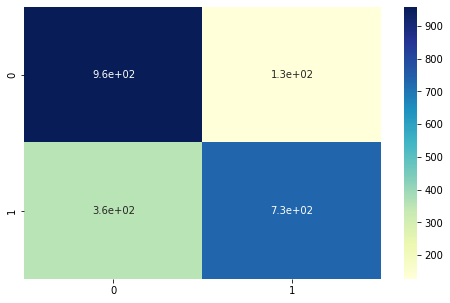

In [ ]:
#Confusion matrix for Logistic regression
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm)
print(cm)
plt.figure(figsize = (8,5))
sns.heatmap(df_cm, annot=True, cmap='YlGnBu')

In [ ]:
#Classififcation report for logistic regression
from sklearn.metrics import classification_report
classification_report(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.88      0.80      1086
           1       0.85      0.67      0.75      1090

    accuracy                           0.78      2176
   macro avg       0.79      0.78      0.77      2176
weighted avg       0.79      0.78      0.77      2176



### KNeighborsClassifier

In [ ]:
def result(name, y_pred):
    """Returns multiple classification metrics of a machine learning algorithm

    :params name: Machine learning algorithm name

    :params y_pred: Prediction results of a machine learning algorithm test set
    """
    print(f'Results of Machine Learning Modelling with {name} Algorithms\n')
    print('-' * 78)
    print(f'\nAccuracy Score :\n{accuracy_score(y_test, y_pred) * 100 } %\n')
    print(f'Confusion Matrix :\n{confusion_matrix(y_test, y_pred)}\n')
    conf = confusion_matrix(y_test, y_pred, normalize='all')
    print('Confusion Matrix with Normalized Value :')
    print('[[{:.3f}  {:.3f}]\n [{:.3f}  {:.3f}]]\n'.format(conf[0,0], conf[0,1], conf[1,0], conf[1,1]))
    print(f'Classification Report :\n{classification_report(y_test, y_pred)}\n')
    print(f'ROC AUC Score :\n{roc_auc_score(y_test, y_pred,)}\n')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
knn_params = {'n_neighbors':np.arange(2,50)}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, refit=True, scoring='roc_auc')
knn_grid.fit(X_train, y_train)
knn_pred = knn_grid.predict(X_test)
result('KNN', knn_pred)


Results of Machine Learning Modelling with KNN Algorithms

------------------------------------------------------------------------------

Accuracy Score :
86.58088235294117 %

Confusion Matrix :
[[978 108]
 [184 906]]

Confusion Matrix with Normalized Value :
[[0.449  0.050]
 [0.085  0.416]]

Classification Report :
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1086
           1       0.89      0.83      0.86      1090

    accuracy                           0.87      2176
   macro avg       0.87      0.87      0.87      2176
weighted avg       0.87      0.87      0.87      2176


ROC AUC Score :
0.865872573369152



###Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
rfc_params = {'min_samples_split':[0.001, 0.0001],
             'n_estimators':[200, 300],
              'criterion':['entropy']
             }
rfc_grid = GridSearchCV(RandomForestClassifier(), rfc_params, scoring='roc_auc', cv=3, refit=True)
rfc_grid.fit(X_train, y_train)
rfc_pred = rfc_grid.predict(X_test)
result('Random Forest Classifier', rfc_pred)

Results of Machine Learning Modelling with Random Forest Classifier Algorithms

------------------------------------------------------------------------------

Accuracy Score :
88.14338235294117 %

Confusion Matrix :
[[988  98]
 [160 930]]

Confusion Matrix with Normalized Value :
[[0.454  0.045]
 [0.074  0.427]]

Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1086
           1       0.90      0.85      0.88      1090

    accuracy                           0.88      2176
   macro avg       0.88      0.88      0.88      2176
weighted avg       0.88      0.88      0.88      2176


ROC AUC Score :
0.8814857992464561



### Decision Tree

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
dt.score(X_test, y_test)

0.8363970588235294

[[912 174]
 [182 908]]


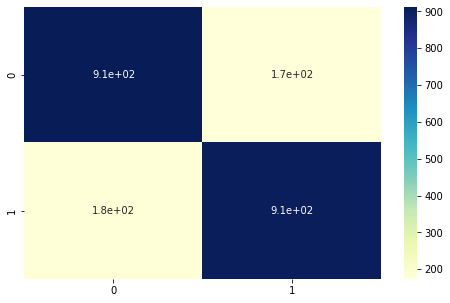

In [ ]:
#Confusion matrix for DecisionTreeClassifier
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm)
plt.figure(figsize = (8,5))
sns.heatmap(df_cm, annot=True, cmap='YlGnBu')
print(cm)

In [ ]:
#Classification report for Decision tree classifier
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.83      0.84      0.84      1086\n           1       0.84      0.83      0.84      1090\n\n    accuracy                           0.84      2176\n   macro avg       0.84      0.84      0.84      2176\nweighted avg       0.84      0.84      0.84      2176\n'